# AI 4 Life Science - Unsupervised Representation Learning - Tutorial 3: Representations (Implicit and Explicit)

## Setup and Groups

**You can choose to remain in the same groups as last time, or repeat the steps from last time with new group members**

Form groups of 3, ideally with people you do not work with regularly. Take 5 min each to explain a bit about your work:

1. What is the focus of your work?

2. What is the limitation or most difficult technical aspect?

3. Could unsupervised learning fit into your project in any way? If so, where could it improve things. If not, why is it unhelpful and what do you wish it could do?


To explore unsupervised learning with code, you can either set up this notebook on your university/lab computer, run it locally, or import it to colab. If you wish to run locally, but do not have anything set up on your machine, we recommend uv for a quick and easy setup:  
https://docs.astral.sh/uv/getting-started/installation/  
After installing uv, you can start a project: https://docs.astral.sh/uv/guides/projects/  
and start up the jupyter notebook with this guide: https://docs.astral.sh/uv/guides/integration/jupyter/  
We will include uv package installation commands throughout (as suggestions), but you are of course free to use your existing environments or preferred packages.

# Data

If you have your own imaging data, setup a data loader or manually load a handful of samples. Ideally choose data that you can compare, e.g. a few different classes or segmentations etc.

If you do not have your own imaging data, you can consider using synthetic test data we have created (or create your own!).  
Our data is hosted at: https://huggingface.co/datasets/Jemtan11/AADD   
And the abdominal test data (recommended) can be found here: https://huggingface.co/datasets/Jemtan11/AADD/tree/main/abdom/test  
Navigate to the different test classes and download one sample per class.

**Alternatively** you can skip down to the model section and select a public dataset associated with that model.

## Reproducible setup and target image

Select **Python 3.12 (AI4LS Workspace)**. We fit two continuous representations to the middle nonblank axial slice from the existing `class0` volume:

1. **Implicit:** a coordinate MLP maps `(x, y) → intensity` using Fourier features.
2. **Explicit:** 128 learned axis-aligned Gaussians store centers, scales, and amplitudes and are composited to render intensity.


In [1]:
%matplotlib inline
import json
from pathlib import Path
from IPython.display import display, Image

file_path = Path('data/class0/aadd_00000.nii.gz')
assert file_path.exists(), f'Missing: {file_path.resolve()}'


# Fit both representations

The implicit model samples coordinate/intensity pairs during optimization. The explicit model is fitted at `64×64` for speed and rendered at `128×128`. Both can be queried on a `256×256` grid without changing their stored representation.


In [2]:
%run tutorial3_representations.py


[TRACE 1/6] Loading representative class0 slice
[TRACE 2/6] Fitting implicit coordinate MLP


/config/workspace/AI4LS_SummerSchool_UnsupervisedRepresentationLearning/tutorial3_representations.py:123: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  implicit_losses.append(float(loss))


Implicit seconds: 8.97 PSNR: 31.48
[TRACE 3/6] Fitting explicit Gaussian representation
Gaussian seconds: 5.69 PSNR: 25.02
[TRACE 4/6] Rendering arbitrary 256x256 resolution
[TRACE 5/6] Saving comparisons and representations
[TRACE 6/6] Complete
{
  "slice_index": 115,
  "target_shape": [
    128,
    128
  ],
  "implicit_parameters": 10113,
  "implicit_seconds": 8.974030597135425,
  "implicit_mae": 0.014320628717541695,
  "implicit_psnr_db": 31.482527236934455,
  "gaussian_count": 128,
  "gaussian_parameters": 640,
  "gaussian_seconds": 5.689282895065844,
  "gaussian_mae": 0.031196851283311844,
  "gaussian_psnr_db": 25.024184531251432
}


In [3]:
tutorial3_output = Path('outputs/tutorial3')
tutorial3_metrics = json.loads((tutorial3_output / 'metrics.json').read_text())
for key, value in tutorial3_metrics.items():
    print(f'{key}: {value}')


slice_index: 115
target_shape: [128, 128]
implicit_parameters: 10113
implicit_seconds: 8.974030597135425
implicit_mae: 0.014320628717541695
implicit_psnr_db: 31.482527236934455
gaussian_count: 128
gaussian_parameters: 640
gaussian_seconds: 5.689282895065844
gaussian_mae: 0.031196851283311844
gaussian_psnr_db: 25.024184531251432


## Reconstruction and error comparison

The coordinate MLP has greater capacity and represents fine structures more accurately. The 128-Gaussian model is much smaller and directly interpretable, but smooth Gaussian primitives blur sharp boundaries and fine texture.


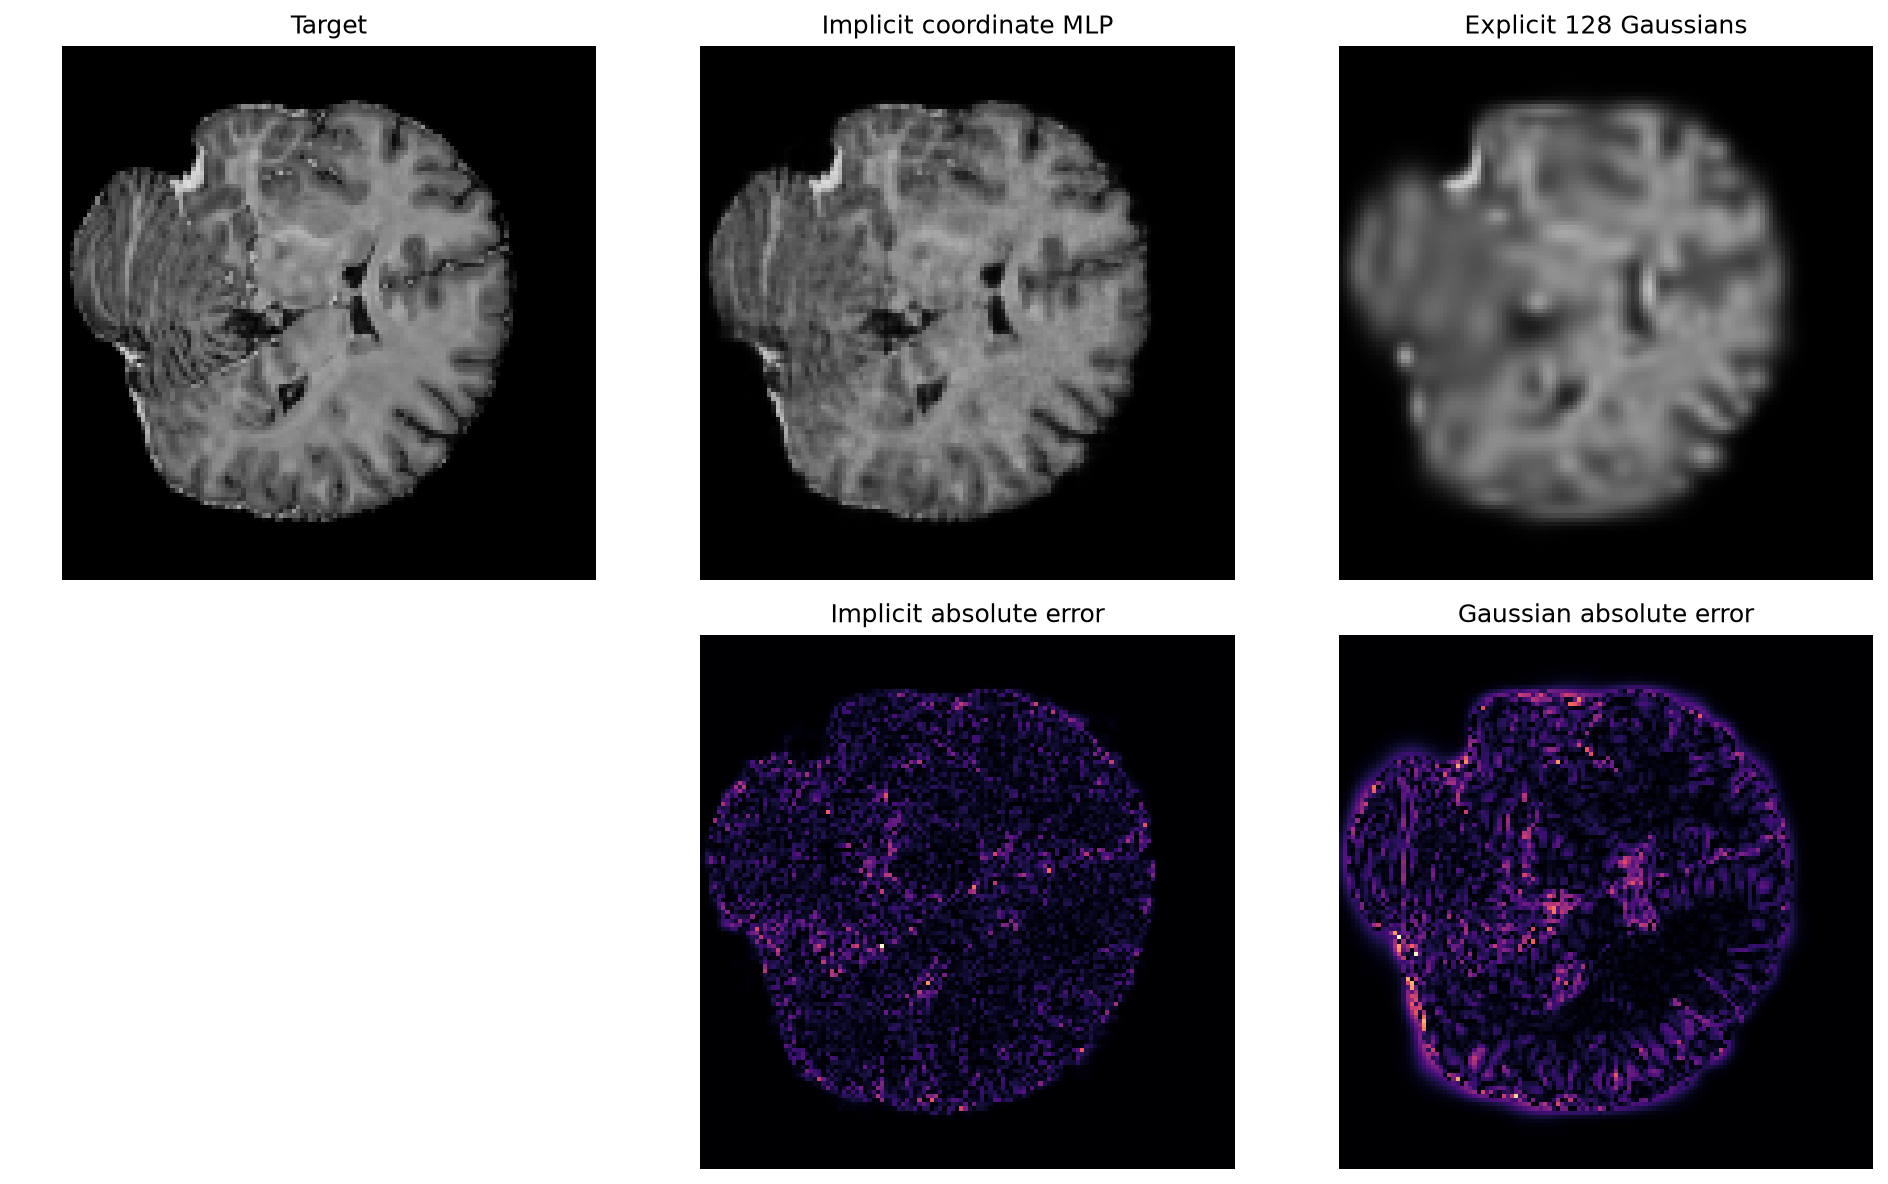

In [4]:
display(Image(filename=str(tutorial3_output / 'representation_comparison.png')))


## Continuous rendering

Both representations can be evaluated at arbitrary coordinates. Rendering at `256×256` demonstrates continuity, but it does not create new measured anatomical detail: it interpolates what the fitted representation learned from the `128×128` target.


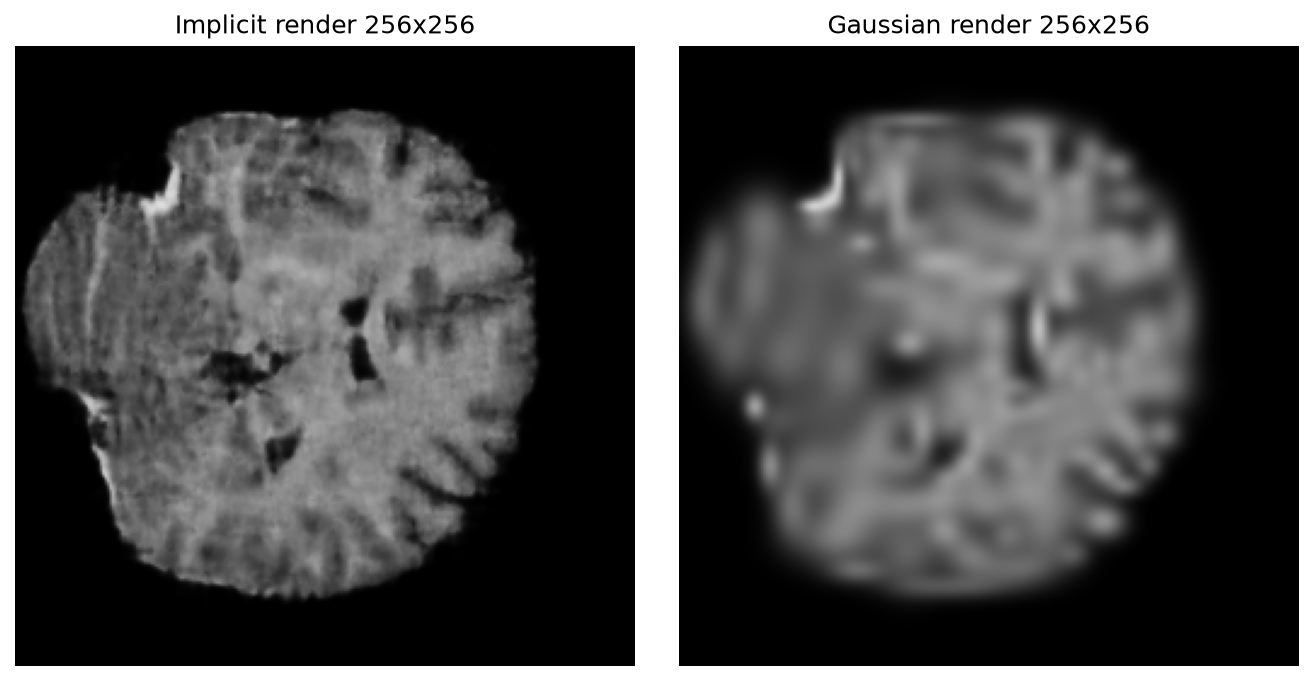

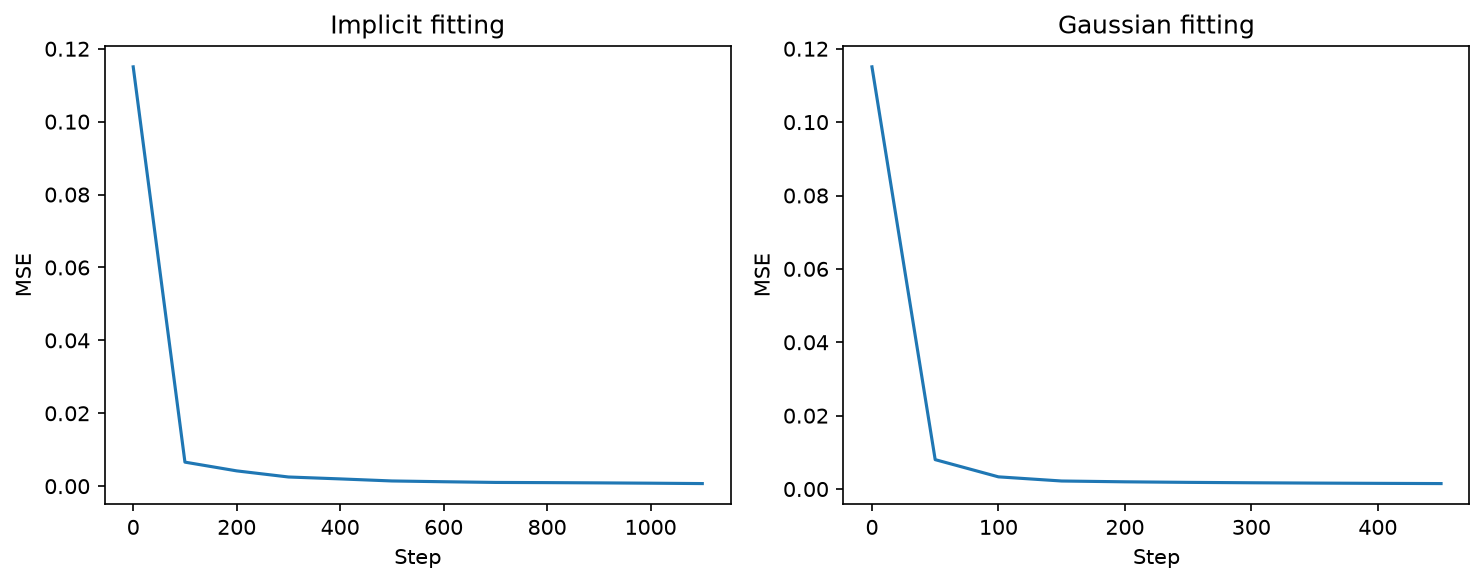

In [5]:
display(Image(filename=str(tutorial3_output / 'arbitrary_resolution.png')))
display(Image(filename=str(tutorial3_output / 'fitting_curves.png')))


# Quantitative comparison


In [6]:
print(
    f"Implicit: {tutorial3_metrics['implicit_parameters']:,} parameters, "
    f"{tutorial3_metrics['implicit_seconds']:.1f}s, "
    f"MAE={tutorial3_metrics['implicit_mae']:.4f}, "
    f"PSNR={tutorial3_metrics['implicit_psnr_db']:.2f} dB"
)
print(
    f"Explicit: {tutorial3_metrics['gaussian_parameters']:,} parameters, "
    f"{tutorial3_metrics['gaussian_seconds']:.1f}s, "
    f"MAE={tutorial3_metrics['gaussian_mae']:.4f}, "
    f"PSNR={tutorial3_metrics['gaussian_psnr_db']:.2f} dB"
)


Implicit: 10,113 parameters, 9.0s, MAE=0.0143, PSNR=31.48 dB
Explicit: 640 parameters, 5.7s, MAE=0.0312, PSNR=25.02 dB


Bad pipe message: %s [b'\r\ncf-connecting-ip: 130.225.188.128\r\ncdn-loop: cloudflare; loops=1\r', b'f-ray: a2', b'6312e8b72da5-CPH\r\npriority: u=0, i\r\naccept-language: en-US,en;q=0.9,zh;q=0.8\r\naccept-encoding: gzip', b'br\r\nreferer: https://koalacode.koalatree.qz']
Bad pipe message: %s [b'io/?folder=/config/workspace\r\nsec-fetch-dest: document\r\nsec-fetch-user: ?1\r\nsec-fetch-mode: navigate\r\nsec-fetch-site: sam']
Bad pipe message: %s [b'origin\r\naccept: text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/ap', b',*/*;q=0.8,application/signed-exchange;v=b3;q=0.7\r\nuser-agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl', b'ebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36\r\nupgrade-insecure-requests: 1\r\nsec-c', b'ua-platform: "Windows"\r\nsec-ch-ua-mobile: ?0\r\nsec-ch-ua: "Not=A?Brand";v="99", "Google Chrome";v="151",', b'Chromium";v="151"\r\nconnection: ']
Bad pipe message: %s [b'grade\r\nx-forwarded-proto: https\r\nx-real

## Which representation is useful downstream?

**Implicit coordinate MLP**

- Best here for compact, high-fidelity continuous rendering (31.48 dB PSNR).
- Differentiable with respect to coordinates; useful for interpolation, registration research, continuous resampling, or coordinate-conditioned analysis.
- Weights are distributed and harder to interpret or edit locally; fitting is image-specific.

**Explicit Gaussians**

- Only 640 learned scalars in this demonstration and fast to render or edit by moving/removing primitives.
- Useful when spatial primitives, sparse structure, local editing, or interpretable geometry matter.
- Lower fidelity here (25.02 dB PSNR); fixed 128 smooth Gaussians miss sharp and fine-scale anatomy.

For segmentation or classification across subjects, neither per-image representation is automatically ideal: fitting each image independently does not align features across subjects. Shared encoders or canonical coordinate systems would be needed. For compression/rendering of individual images, the implicit model gives the strongest fidelity-size tradeoff in this experiment.
